# AI & ML – Task 2: Feature Engineering, Model Optimization & Performance Comparison
**Dataset:** California Housing (scikit-learn) | **Target:** Median House Value (in $100,000s)

**Pipeline:** load data → inspect → split → scale (no leakage) → train 3 models → compare with RMSE & R² → validate visually → select & save best model.

## Step 1: Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")

## Step 2: Load the Dataset

In [2]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)
print("Shape:", df.shape)
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.info()
print("\nMissing values:", df.isnull().sum().sum())
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Missing values: 0


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
HousePrice,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


Features sit on very different numeric ranges (e.g. `Population` in the thousands vs `MedInc` around 1–15), which is why scaling matters for Ridge Regression.

## Step 3: Separate Features and Target

In [4]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]
print(X.shape, y.shape)

(20640, 8) (20640,)


## Step 4: Train–Test Split (done *before* scaling)
Splitting first means the test set never influences the scaler's mean/std, which avoids **data leakage**.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (16512, 8) | Test: (4128, 8)


## Step 5: Feature Scaling (Critical Step)
The scaler is **fit on training data only**, then applied to the test data.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pd.DataFrame(X_train_scaled, columns=X.columns).describe().loc[["mean", "std"]].round(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
mean,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Step 6: Train Multiple Models
- **Linear Regression** – baseline
- **Ridge Regression** – L2 regularisation to reduce overfitting
- **Decision Tree** – captures non-linear relationships

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"Trained: {name}")

Trained: Linear Regression
Trained: Ridge Regression
Trained: Decision Tree


Trained: Decision Tree


## Step 7: Model Evaluation and Comparison
Lower RMSE = better accuracy; higher R² = better explanatory power. Train metrics are included to check for **overfitting** (a large train–test gap).

In [8]:
results = {}
for name, model in models.items():
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    results[name] = {
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred),
        "Test MAE": mean_absolute_error(y_test, test_pred),
    }

results_df = pd.DataFrame(results).T.round(4)
results_df.to_csv("model_comparison_table.csv")

# Reference point: a model that always predicts the training mean (same one used in Task 1)
dummy = DummyRegressor(strategy="mean").fit(X_train_scaled, y_train)
dummy_pred = dummy.predict(X_test_scaled)
dummy_rmse = np.sqrt(mean_squared_error(y_test, dummy_pred))
dummy_r2 = r2_score(y_test, dummy_pred)
print(f"Mean-only baseline -> Test RMSE: {dummy_rmse:.4f} | Test R2: {dummy_r2:.4f}")
results_df

Mean-only baseline -> Test RMSE: 1.1449 | Test R2: -0.0002


,Train RMSE,Test RMSE,Train R2,Test R2,Test MAE
Linear Regression,0.7197,0.7456,0.6126,0.5758,0.5332
Ridge Regression,0.7197,0.7456,0.6126,0.5758,0.5332
Decision Tree,0.6959,0.7242,0.6377,0.5997,0.5223


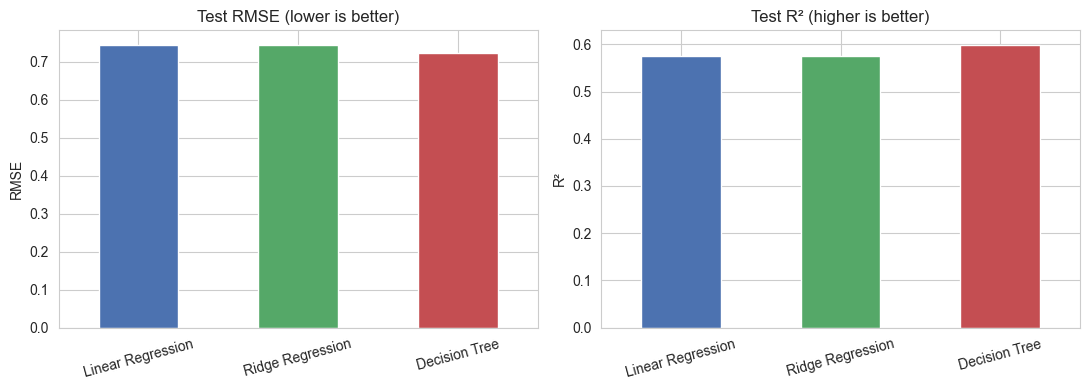

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
results_df["Test RMSE"].plot(kind="bar", ax=ax[0], color=["#4C72B0", "#55A868", "#C44E52"])
ax[0].set_title("Test RMSE (lower is better)"); ax[0].set_ylabel("RMSE")
results_df["Test R2"].plot(kind="bar", ax=ax[1], color=["#4C72B0", "#55A868", "#C44E52"])
ax[1].set_title("Test R² (higher is better)"); ax[1].set_ylabel("R²")
for a in ax: a.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.savefig("model_comparison.png", dpi=150); plt.show()

## Step 8: Select the Best Model (data-driven, not hardcoded)

In [10]:
best_name = results_df["Test RMSE"].idxmin()
best_model = models[best_name]
print("Best model:", best_name)
print(results_df.loc[best_name])

Best model: Decision Tree
Train RMSE    0.6959
Test RMSE     0.7242
Train R2      0.6377
Test R2       0.5997
Test MAE      0.5223
Name: Decision Tree, dtype: float64


## Step 9: Visual Performance Validation

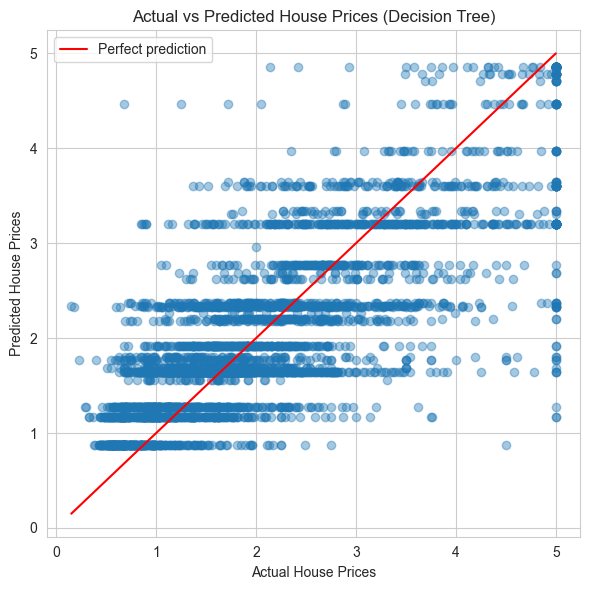

In [11]:
y_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", label="Perfect prediction")
plt.xlabel("Actual House Prices"); plt.ylabel("Predicted House Prices")
plt.title(f"Actual vs Predicted House Prices ({best_name})")
plt.legend(); plt.tight_layout(); plt.savefig("actual_vs_predicted.png", dpi=150); plt.show()

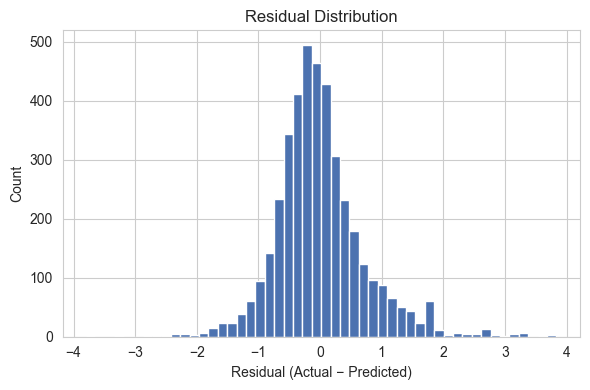

In [12]:
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=50, color="#4C72B0")
plt.xlabel("Residual (Actual − Predicted)"); plt.ylabel("Count"); plt.title("Residual Distribution")
plt.tight_layout(); plt.savefig("residuals.png", dpi=150); plt.show()

## Step 10 (Optional): Save the Best Model

In [13]:
joblib.dump({"scaler": scaler, "model": best_model}, "best_house_price_model.joblib")
print("Saved best_house_price_model.joblib")

Saved best_house_price_model.joblib


## Step 11: Auto-generate the 1–2 Page PDF Report
This cell builds the PDF from **your own results**, so the numbers in the report always match the notebook. (Needs `pip install reportlab` if not installed.)

In [14]:
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image

ss = getSampleStyleSheet()
H = ParagraphStyle("H", parent=ss["Heading2"], fontSize=12, spaceBefore=6, spaceAfter=3, keepWithNext=1)
B = ParagraphStyle("B", parent=ss["BodyText"], fontSize=9.5, leading=12.5)

r = results_df
b = r.loc[best_name]
lin = r.loc["Linear Regression"]
gap = b["Train R2"] - b["Test R2"]
improve = (lin["Test RMSE"] - b["Test RMSE"]) / lin["Test RMSE"] * 100

story = [
    Paragraph("AI &amp; ML Task 2: Model Comparison on California Housing", ss["Title"]),
    Paragraph("Feature Engineering, Model Optimization &amp; Performance Comparison", ss["Italic"]),
    Paragraph("1. Objective", H),
    Paragraph("Improve on the Task 1 baseline by preparing the data properly, training several regression "
              "algorithms, and choosing the final model using measurable metrics (RMSE and R<super>2</super>).", B),
    Paragraph("2. Methodology", H),
    Paragraph("<b>Data:</b> California Housing dataset (20,640 districts, 8 numeric features; target = median house value "
              "in $100,000s; no missing values).<br/>"
              "<b>Split before scaling:</b> 80/20 train-test split (random_state=42). <b>StandardScaler</b> was fit on the "
              "training set only and then applied to the test set, which prevents data leakage.<br/>"
              "<b>Models:</b> Linear Regression (baseline), Ridge Regression (alpha=1.0, L2 regularisation) and Decision Tree "
              "Regressor (max_depth=5, captures non-linear patterns).<br/>"
              "<b>Metrics:</b> RMSE (lower is better) and R<super>2</super> (higher is better) on the unseen test set; train metrics were "
              "also computed to check for overfitting.", B),
    Paragraph("3. Results", H),
]
rows = [["Model", "Train RMSE", "Test RMSE", "Test MAE", "Train R2", "Test R2"]]
for n, row in r.iterrows():
    rows.append([n] + [f"{row[c]:.4f}" for c in ["Train RMSE", "Test RMSE", "Test MAE", "Train R2", "Test R2"]])
t = Table(rows, hAlign="LEFT", colWidths=[3.8*cm, 2.6*cm, 2.6*cm, 2.6*cm, 2.6*cm, 2.6*cm])
t.setStyle(TableStyle([
    ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#1F3A5F")), ("TEXTCOLOR", (0,0), (-1,0), colors.white),
    ("FONTSIZE", (0,0), (-1,-1), 9), ("GRID", (0,0), (-1,-1), 0.4, colors.grey),
    ("ALIGN", (1,0), (-1,-1), "CENTER"),
    ("BACKGROUND", (0, list(r.index).index(best_name)+1), (-1, list(r.index).index(best_name)+1), colors.HexColor("#E3F0E3")),
]))
story += [t, Spacer(1, 6),
          Image("model_comparison.png", width=13*cm, height=13*cm*4/11), Spacer(1, 4),
          Image("actual_vs_predicted.png", width=6.5*cm, height=6.5*cm),
          Paragraph("Figure: Actual vs Predicted prices for the selected model. Points closer to the red line mean better predictions.", B),
          Paragraph("4. Analysis and Conclusion", H),
          Paragraph(f"<b>{best_name}</b> was selected because it had the lowest test RMSE ({b['Test RMSE']:.4f}) and the highest test "
                    f"R<super>2</super> ({b['Test R2']:.4f}). Compared with the Linear Regression baseline (RMSE {lin['Test RMSE']:.4f}, "
                    f"R<super>2</super> {lin['Test R2']:.4f}), test RMSE {'dropped' if improve >= 0 else 'rose'} by {abs(improve):.1f}%. "
                    f"The train-test R<super>2</super> gap for the chosen model is {gap:.3f}, "
                    f"{'which is small, so there is no strong sign of overfitting.' if gap < 0.05 else 'which suggests some overfitting; tuning max_depth or using cross-validation would help.'} "
                    "Ridge Regression matched Linear Regression almost exactly: with thousands of training rows and only 8 features, "
                    "a small penalty (alpha=1.0) barely changes the coefficients, so the limit is model flexibility (underfitting), not "
                    "overfitting. The Decision Tree can capture non-linear effects such as the coastal location pattern, which is why it "
                    f"scores higher. A model that always predicts the mean scores R<super>2</super> = {dummy_r2:.2f}, so all three models add real signal. "
                    "The Linear Regression row uses the same 80/20 split (random_state=42) as Task 1, so it is directly comparable to the Task 1 result. "
                    "Scaling was fit on the training set only to keep the evaluation honest.", B),
          Paragraph("<b>Next steps:</b> cross-validation, hyperparameter tuning (GridSearchCV), and ensemble models such as "
                    "Random Forest or Gradient Boosting (HistGradientBoostingRegressor reached R<super>2</super> of about 0.83 in the Task 1 experiment).", B)]
SimpleDocTemplate("AI_ML_Task2_Report.pdf", pagesize=A4, leftMargin=2*cm, rightMargin=2*cm,
                  topMargin=1.5*cm, bottomMargin=1.5*cm).build(story)
print("Report saved: AI_ML_Task2_Report.pdf")

ModuleNotFoundError: No module named 'reportlab'

## Conclusion
The final model is chosen automatically by lowest test RMSE (Step 8) and justified in the generated PDF report. Add your own interpretation here after running the notebook.